# DineIQ Analytics — Exploratory Data Analysis (SRS Step 8)

**Author:** DineIQ Big Data & Data Science Engineering Team  
**Scope:** Comprehensive exploratory analysis across operational restaurant datasets to identify the **EXACT 13 analytical items** designated in the Software Requirements Specification (SRS v1.0, Step 8).

---

### The 13 SRS Deliverable Focus Areas:
1. **Top-Selling Dishes** (sales volume & order frequency)
2. **Lowest-Selling Dishes** (cold items & menu fatigue)
3. **Highest-Revenue Dishes** (dollar contribution)
4. **Highest-Profit Dishes** (absolute contribution margin)
5. **Highest-Margin Dishes** (margin % & price-to-cost markup)
6. **High-Wastage Dishes** (financial loss & prep spoilage)
7. **Best-Rated Dishes** (customer satisfaction & review counts)
8. **Poorly Rated Dishes** (negative sentiment & quality flags)
9. **Popular Menu Categories** (category revenue, volume, target margin alignment)
10. **Peak Ordering Periods** (hourly, meal period, day-of-week demand)
11. **Location-Wise Sales Patterns** (urban vs suburban performance, cost index)
12. **Channel-Wise Ordering Patterns** (Dine-in vs Takeout vs Delivery)
13. **Promotion-Driven Sales** (discount lift, promotional dependency, campaign ROI)


In [1]:
# Environment Setup & Core Library Imports
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import pyarrow.parquet as pq

# Set visual styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

PROJECT_ROOT = os.path.abspath("..")
PARQUET_FEATURES = os.path.join(PROJECT_ROOT, "parquet_data", "features")
CLEANED_DIR = os.path.join(PROJECT_ROOT, "processed_data", "cleaned")
JOINED_DIR = os.path.join(PROJECT_ROOT, "processed_data", "joined")

print("Project Root:", PROJECT_ROOT)
print("Environment Ready.")


Project Root: C:\Users\HP 250 G9\OneDrive\Desktop\techwiz-Inside Hunters SFC
Environment Ready.


In [2]:
# Ingest Engineered Feature Marts & Operational Datasets
menu_df = pd.read_parquet(os.path.join(PARQUET_FEATURES, "menu_features.parquet"))
cust_df = pd.read_parquet(os.path.join(PARQUET_FEATURES, "customer_master_features.parquet"))
orders_df = pd.read_parquet(os.path.join(CLEANED_DIR, "orders", "orders.parquet"))
order_items_df = pd.read_parquet(os.path.join(CLEANED_DIR, "order_items", "order_items.parquet"))
restaurants_df = pd.read_parquet(os.path.join(CLEANED_DIR, "restaurants", "restaurants.parquet"))
ratings_df = pd.read_parquet(os.path.join(CLEANED_DIR, "ratings", "ratings.parquet"))
wastage_df = pd.read_parquet(os.path.join(CLEANED_DIR, "wastage", "wastage.parquet"))
categories_df = pd.read_parquet(os.path.join(CLEANED_DIR, "menu_categories", "menu_categories.parquet"))

print(f"Loaded {len(menu_df)} menu items, {len(orders_df):,} orders, {len(order_items_df):,} line items, and {len(cust_df):,} customers.")


Loaded 150 menu items, 90,471 orders, 904,502 line items, and 50,000 customers.


## 1. Top-Selling Dishes
Items with the highest sales volume (units sold) and order frequency across all restaurant locations.


In [3]:
top_selling = menu_df.sort_values(by="item_popularity", ascending=False).head(10)
display_cols = ["item_id", "item_name", "category_name", "item_popularity", "order_frequency", "base_price", "item_revenue"]
top_selling[display_cols]


,item_id,item_name,category_name,item_popularity,order_frequency,base_price,item_revenue
116,ITEM-136,DineIQ House Drip Roast Coffee,Specialty Coffee & Beverages,21480,13670,3.99,85705.20
8,ITEM-016,DineIQ Smash Double Cheeseburger,Artisanal Burgers & Handhelds,19852,12728,13.99,277729.48
5,ITEM-031,Margherita Sourdough Pizza,Wood-Fired Pizzas & Pastas,18735,12146,15.99,299572.65
83,ITEM-121,DineIQ House Draft Lager (Pint),Signature Cocktails & Mocktails,18672,12038,6.50,121368.00
2,ITEM-032,Double Pepperoni Hot Honey Pizza,Wood-Fired Pizzas & Pastas,18644,12038,18.50,344914.00
47,ITEM-001,Crispy Parmesan Truffle Fries,Appetizers & Small Plates,18011,11566,8.99,161918.89
101,ITEM-139,Vanilla Bean Oat Milk Latte,Specialty Coffee & Beverages,17901,11410,5.75,102930.75
12,ITEM-017,Crispy Buttermilk Chicken Sandwich,Artisanal Burgers & Handhelds,17296,11181,14.50,250792.00
31,ITEM-106,Molten Chocolate Lava Cake,Handcrafted Desserts & Pastries,17034,10982,10.99,187203.66
14,ITEM-002,Classic Buffalo Chicken Wings,Appetizers & Small Plates,16816,10892,14.50,243832.00


C:\Users\HP 250 G9\AppData\Local\Temp\ipykernel_23420\3738666130.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_selling, x="item_popularity", y="item_name", palette="viridis", ax=ax)


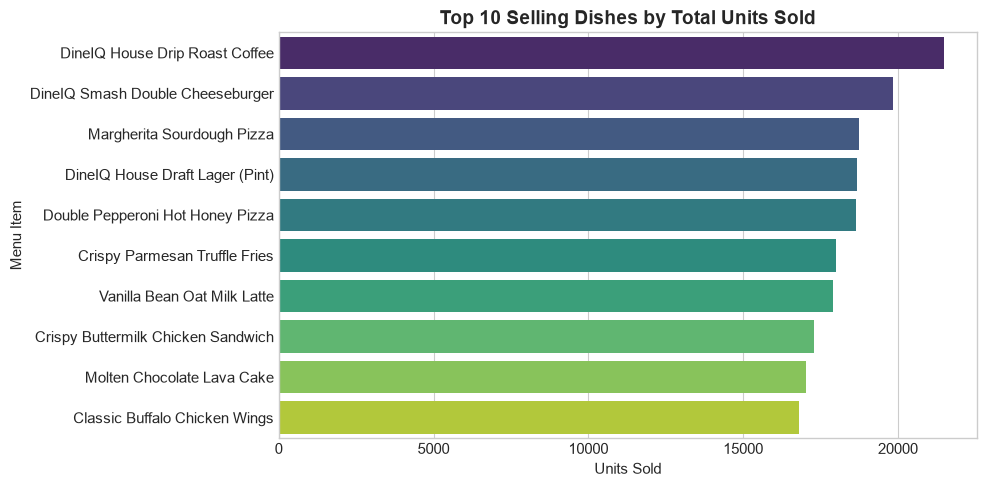

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top_selling, x="item_popularity", y="item_name", palette="viridis", ax=ax)
ax.set_title("Top 10 Selling Dishes by Total Units Sold", fontsize=14, fontweight="bold")
ax.set_xlabel("Units Sold")
ax.set_ylabel("Menu Item")
plt.tight_layout()
plt.show()


## 2. Lowest-Selling Dishes
Dishes with the lowest order volume, representing slow-moving inventory, niche appeal, or customer fatigue.


In [5]:
lowest_selling = menu_df.sort_values(by="item_popularity", ascending=True).head(10)
lowest_selling[display_cols]


,item_id,item_name,category_name,item_popularity,order_frequency,base_price,item_revenue
128,ITEM-051,A5 Miyazaki Japanese Wagyu (4oz),Prime Steaks & Butcher Cuts,667,457,95.0,63365.0
141,ITEM-008,Reserve Osetra Caviar Blinis,Appetizers & Small Plates,814,574,36.3,52910.0
79,ITEM-047,Dry-Aged Tomahawk Ribeye (36oz),Prime Steaks & Butcher Cuts,987,677,125.0,123375.0
139,ITEM-133,Rare Japanese Whisky Flight (3-pour),Signature Cocktails & Mocktails,1038,712,55.0,57090.0
125,ITEM-060,Pepper-Crusted Bison Tenderloin,Prime Steaks & Butcher Cuts,1145,794,58.0,66410.0
134,ITEM-057,Roasted Veal Chop Chanterelles,Prime Steaks & Butcher Cuts,1208,843,49.0,59192.0
147,ITEM-113,Vintage Champagne Berry Float,Handcrafted Desserts & Pastries,1351,901,24.0,32424.0
149,ITEM-149,Rare Blue Mountain Jamaican Pour-Over,Specialty Coffee & Beverages,1482,1020,12.0,17784.0
145,ITEM-125,Black Truffle Infused Manhattan,Signature Cocktails & Mocktails,1691,1127,28.0,47348.0
148,ITEM-118,Dark Chocolate Souffle Grand Marnier,Handcrafted Desserts & Pastries,1762,1212,16.5,29073.0


C:\Users\HP 250 G9\AppData\Local\Temp\ipykernel_23420\4080327963.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lowest_selling, x="item_popularity", y="item_name", palette="rocket", ax=ax)


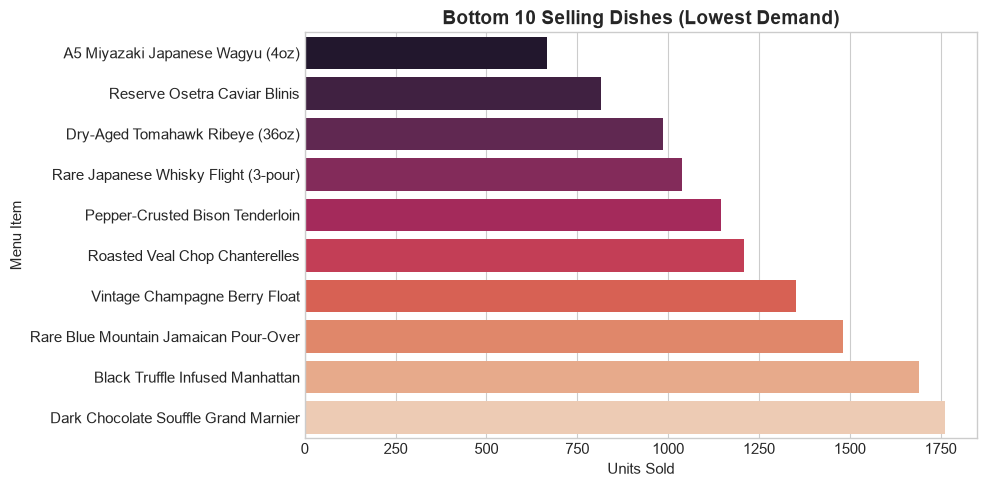

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=lowest_selling, x="item_popularity", y="item_name", palette="rocket", ax=ax)
ax.set_title("Bottom 10 Selling Dishes (Lowest Demand)", fontsize=14, fontweight="bold")
ax.set_xlabel("Units Sold")
ax.set_ylabel("Menu Item")
plt.tight_layout()
plt.show()


## 3. Highest-Revenue Dishes
Dishes generating the highest gross dollar inflow for the restaurant enterprise.


In [7]:
highest_revenue = menu_df.sort_values(by="item_revenue", ascending=False).head(10)
highest_revenue[["item_id", "item_name", "category_name", "base_price", "item_popularity", "item_revenue", "cost", "contribution_margin"]]


,item_id,item_name,category_name,base_price,item_popularity,item_revenue,cost,contribution_margin
0,ITEM-052,Steak Frites Garlic Herb Butter,Prime Steaks & Butcher Cuts,29.99,13931,417790.69,257723.5,160067.19
1,ITEM-046,USDA Prime Center-Cut Filet Mignon (8oz),Prime Steaks & Butcher Cuts,48.00,7328,351744.00,179536.0,172208.00
2,ITEM-032,Double Pepperoni Hot Honey Pizza,Wood-Fired Pizzas & Pastas,18.50,18644,344914.00,257287.2,87626.80
3,ITEM-063,Wild King Salmon Lemon Herb,Chef Specials & Seafood,34.00,9196,312664.00,148975.2,163688.80
4,ITEM-068,Classic Fish & Chips Tartar,Chef Specials & Seafood,19.99,15137,302588.63,219486.5,83102.13
5,ITEM-031,Margherita Sourdough Pizza,Wood-Fired Pizzas & Pastas,15.99,18735,299572.65,224820.0,74752.65
6,ITEM-050,Slow-Braised Beef Short Ribs,Prime Steaks & Butcher Cuts,36.00,8234,296424.00,119393.0,177031.00
7,ITEM-054,Coffee-Crusted Prime Ribeye (14oz),Prime Steaks & Butcher Cuts,52.00,5491,285532.00,126293.0,159239.00
8,ITEM-016,DineIQ Smash Double Cheeseburger,Artisanal Burgers & Handhelds,13.99,19852,277729.48,214401.6,63327.88
9,ITEM-058,BBQ Glazed St. Louis Ribs (Full),Prime Steaks & Butcher Cuts,31.00,8732,270692.00,122248.0,148444.00


C:\Users\HP 250 G9\AppData\Local\Temp\ipykernel_23420\2369521663.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=highest_revenue, x="item_revenue", y="item_name", palette="mako", ax=ax)


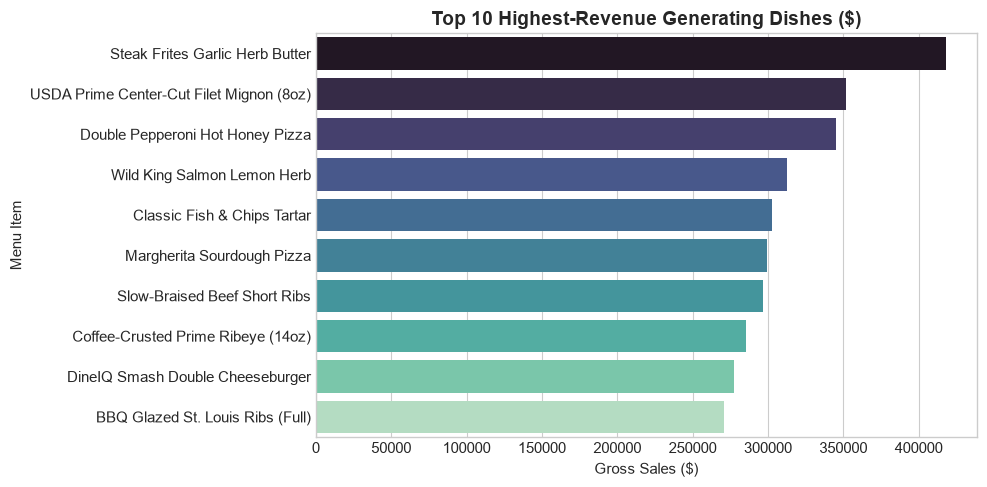

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=highest_revenue, x="item_revenue", y="item_name", palette="mako", ax=ax)
ax.set_title("Top 10 Highest-Revenue Generating Dishes ($)", fontsize=14, fontweight="bold")
ax.set_xlabel("Gross Sales ($)")
ax.set_ylabel("Menu Item")
plt.tight_layout()
plt.show()


## 4. Highest-Profit Dishes
Dishes delivering the greatest absolute dollar profit (`revenue - ingredients/prep cost`).


In [9]:
highest_profit = menu_df.sort_values(by="contribution_margin", ascending=False).head(10)
highest_profit[["item_id", "item_name", "category_name", "item_revenue", "cost", "contribution_margin", "profit_percentage"]]


,item_id,item_name,category_name,item_revenue,cost,contribution_margin,profit_percentage
6,ITEM-050,Slow-Braised Beef Short Ribs,Prime Steaks & Butcher Cuts,296424.00,119393.0,177031.00,59.72
17,ITEM-135,Red Sangria Pitcher (House Wine),Signature Cocktails & Mocktails,224083.00,47907.4,176175.60,78.62
1,ITEM-046,USDA Prime Center-Cut Filet Mignon (8oz),Prime Steaks & Butcher Cuts,351744.00,179536.0,172208.00,48.96
13,ITEM-038,Creamy Fettuccine Alfredo,Wood-Fired Pizzas & Pastas,245284.63,75072.4,170212.23,69.39
3,ITEM-063,Wild King Salmon Lemon Herb,Chef Specials & Seafood,312664.00,148975.2,163688.80,52.35
23,ITEM-122,Signature Smoked Old Fashioned,Signature Cocktails & Mocktails,204512.00,40902.4,163609.60,80.00
25,ITEM-126,Espresso Martini Vanilla Foam,Signature Cocktails & Mocktails,202710.00,39190.6,163519.40,80.67
0,ITEM-052,Steak Frites Garlic Herb Butter,Prime Steaks & Butcher Cuts,417790.69,257723.5,160067.19,38.31
28,ITEM-132,Aperol Spritz Prosecco Orange,Signature Cocktails & Mocktails,196125.81,36449.4,159676.41,81.42
7,ITEM-054,Coffee-Crusted Prime Ribeye (14oz),Prime Steaks & Butcher Cuts,285532.00,126293.0,159239.00,55.77


C:\Users\HP 250 G9\AppData\Local\Temp\ipykernel_23420\2345234827.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=highest_profit, x="contribution_margin", y="item_name", palette="crest", ax=ax)


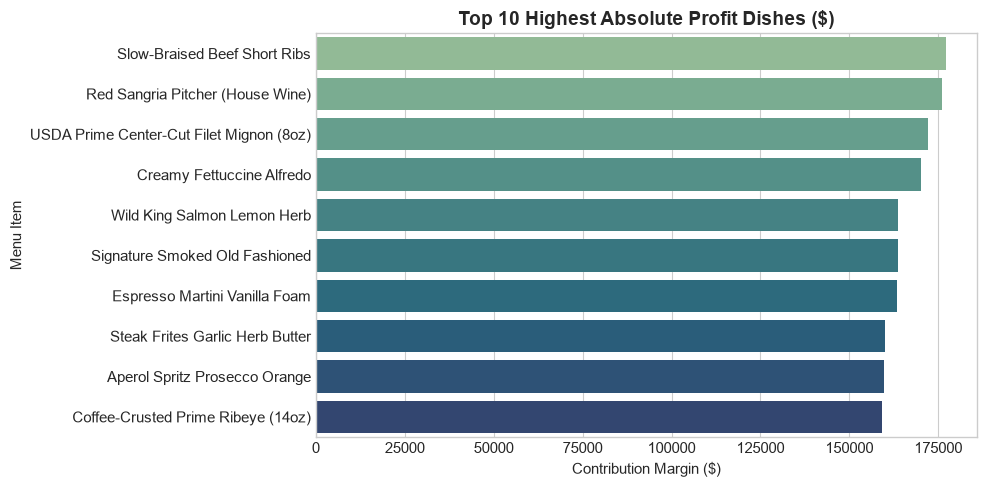

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=highest_profit, x="contribution_margin", y="item_name", palette="crest", ax=ax)
ax.set_title("Top 10 Highest Absolute Profit Dishes ($)", fontsize=14, fontweight="bold")
ax.set_xlabel("Contribution Margin ($)")
ax.set_ylabel("Menu Item")
plt.tight_layout()
plt.show()


## 5. Highest-Margin Dishes
Dishes with the highest percentage profit margin (`(revenue - cost) / revenue * 100`).


In [11]:
highest_margin = menu_df[menu_df["item_popularity"] >= 1000].sort_values(by="profit_percentage", ascending=False).head(10)
highest_margin[["item_id", "item_name", "category_name", "base_price", "cost_price", "profit_percentage", "contribution_margin"]]


,item_id,item_name,category_name,base_price,cost_price,profit_percentage,contribution_margin
146,ITEM-143,Organic Earl Grey Loose Leaf Tea,Specialty Coffee & Beverages,4.25,0.45,89.41,35465.40
138,ITEM-138,Double Espresso Single Origin,Specialty Coffee & Beverages,3.50,0.50,85.71,48954.00
116,ITEM-136,DineIQ House Drip Roast Coffee,Specialty Coffee & Beverages,3.99,0.60,84.96,72817.20
145,ITEM-125,Black Truffle Infused Manhattan,Signature Cocktails & Mocktails,28.00,4.50,83.93,39738.50
140,ITEM-142,Spiced Masala Chai Latte,Specialty Coffee & Beverages,5.25,0.90,82.86,46170.90
106,ITEM-137,Nitro Cold Brew Sweet Cream,Specialty Coffee & Beverages,5.99,1.10,81.64,76137.30
39,ITEM-130,Classic Moscow Mule Copper Mug,Signature Cocktails & Mocktails,13.50,2.50,81.48,137489.00
28,ITEM-132,Aperol Spritz Prosecco Orange,Signature Cocktails & Mocktails,13.99,2.60,81.42,159676.41
108,ITEM-127,Zero-Proof Cucumber Mint Cooler,Signature Cocktails & Mocktails,8.50,1.60,81.18,74582.10
66,ITEM-131,Yuzu Lavender Gin Tonic,Signature Cocktails & Mocktails,14.00,2.70,80.71,111316.30


C:\Users\HP 250 G9\AppData\Local\Temp\ipykernel_23420\3289964094.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=highest_margin, x="profit_percentage", y="item_name", palette="coolwarm", ax=ax)


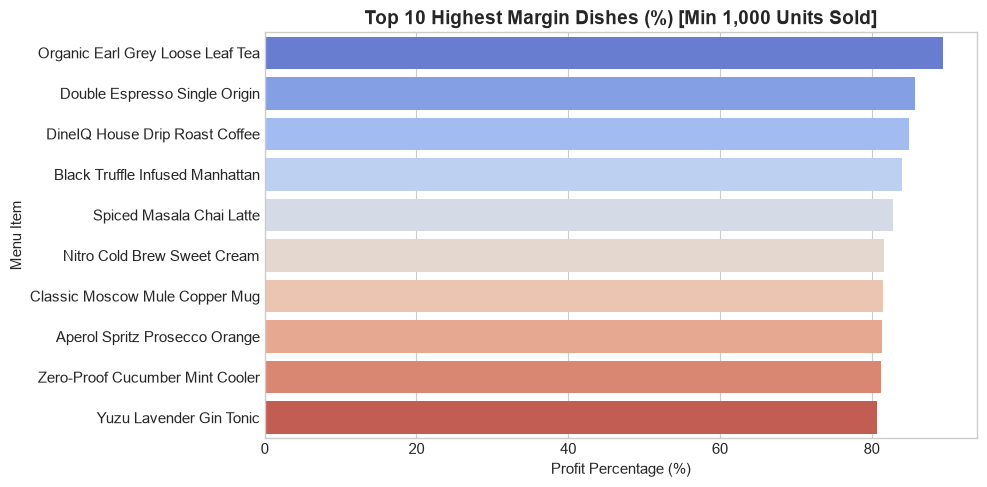

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=highest_margin, x="profit_percentage", y="item_name", palette="coolwarm", ax=ax)
ax.set_title("Top 10 Highest Margin Dishes (%) [Min 1,000 Units Sold]", fontsize=14, fontweight="bold")
ax.set_xlabel("Profit Percentage (%)")
ax.set_ylabel("Menu Item")
plt.tight_layout()
plt.show()


## 6. High-Wastage Dishes
Dishes suffering the highest wastage percentage and financial loss from preparation spoilage and expiration.


In [13]:
waste_agg = wastage_df.groupby("item_id").agg(
    total_wasted_qty=("quantity_wasted", "sum"),
    total_dollar_loss=("total_loss_amount", "sum")
).reset_index()

menu_waste = pd.merge(menu_df, waste_agg, on="item_id", how="left").fillna(0)
high_wastage = menu_waste.sort_values(by="total_dollar_loss", ascending=False).head(10)
high_wastage[["item_id", "item_name", "category_name", "total_wasted_qty", "total_dollar_loss", "wastage_percentage", "item_popularity"]]


,item_id,item_name,category_name,total_wasted_qty,total_dollar_loss,wastage_percentage,item_popularity
81,ITEM-064,Butter Poached Maine Lobster Tail,Chef Specials & Seafood,9564,224754.0,80.25,2354
92,ITEM-075,Seafood Bouillabaisse Saffron Rouille,Chef Specials & Seafood,9215,152047.5,75.82,2939
52,ITEM-066,Seared Diver Scallops Sweet Corn,Chef Specials & Seafood,8933,150074.4,67.77,4249
113,ITEM-072,Whole Grilled Red Snapper Mojo,Chef Specials & Seafood,8505,148837.5,80.27,2091
70,ITEM-062,Crispy Skin Mediterranean Branzino,Chef Specials & Seafood,8631,138096.0,71.21,3489
27,ITEM-067,Seafood Paella Valenciana,Chef Specials & Seafood,8465,135440.0,59.74,5705
53,ITEM-069,Grilled Yellowfin Ahi Tuna Steak,Chef Specials & Seafood,8832,130713.6,65.71,4608
42,ITEM-065,Jumbo Lump Crab Cakes (2pcs),Chef Specials & Seafood,7916,118740.0,60.44,5182
100,ITEM-045,Linguine alle Vongole (Clams),Wood-Fired Pizzas & Pastas,9147,109764.0,68.85,4139
121,ITEM-005,Wild Alaskan Salmon Tartare,Appetizers & Small Plates,9217,105995.5,72.23,3544


C:\Users\HP 250 G9\AppData\Local\Temp\ipykernel_23420\1818736115.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=high_wastage, x="total_dollar_loss", y="item_name", palette="Reds_r", ax=ax1)


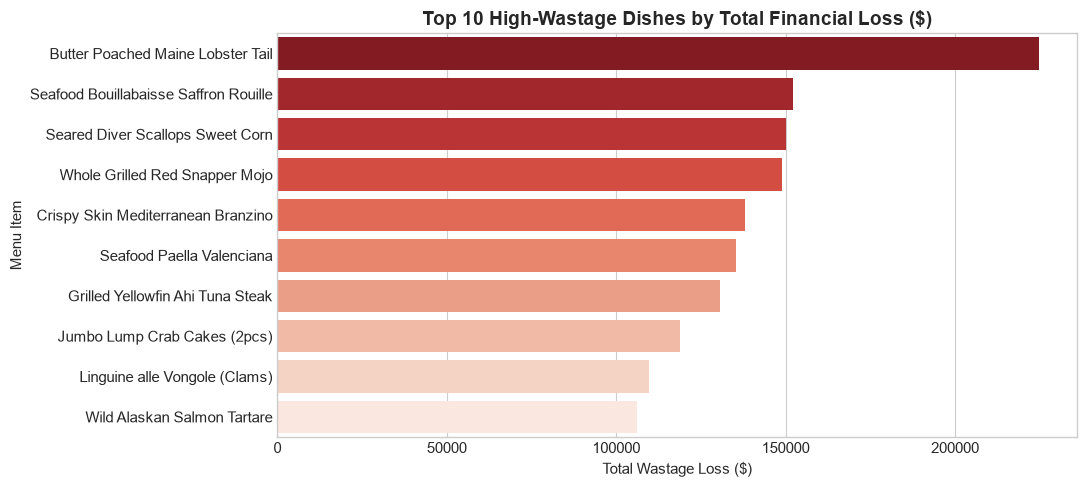

In [14]:
fig, ax1 = plt.subplots(figsize=(11, 5))
sns.barplot(data=high_wastage, x="total_dollar_loss", y="item_name", palette="Reds_r", ax=ax1)
ax1.set_title("Top 10 High-Wastage Dishes by Total Financial Loss ($)", fontsize=14, fontweight="bold")
ax1.set_xlabel("Total Wastage Loss ($)")
ax1.set_ylabel("Menu Item")
plt.tight_layout()
plt.show()


## 7. Best-Rated Dishes
Items receiving the highest customer satisfaction ratings (overall rating, food quality, and service).


In [15]:
best_rated = menu_df.sort_values(by="average_rating", ascending=False).head(10)
best_rated[["item_id", "item_name", "category_name", "average_rating", "rating_trend", "item_popularity"]]


,item_id,item_name,category_name,average_rating,rating_trend,item_popularity
75,ITEM-097,Jackfruit Smoky Carnitas Tacos,Vegan & Plant-Based Creations,3.82,0.089,8319
134,ITEM-057,Roasted Veal Chop Chanterelles,Prime Steaks & Butcher Cuts,3.79,0.464,1208
129,ITEM-090,Warm Roasted Butternut Squash Bowl,Farm-Fresh Salads & Grain Bowls,3.77,-0.218,4526
113,ITEM-072,Whole Grilled Red Snapper Mojo,Chef Specials & Seafood,3.77,0.398,2091
148,ITEM-118,Dark Chocolate Souffle Grand Marnier,Handcrafted Desserts & Pastries,3.77,0.644,1762
62,ITEM-011,Spicy Tuna Crispy Rice,Appetizers & Small Plates,3.76,-0.110,7852
145,ITEM-125,Black Truffle Infused Manhattan,Signature Cocktails & Mocktails,3.75,0.114,1691
58,ITEM-036,Slow-Braised Wild Boar Pappardelle,Wood-Fired Pizzas & Pastas,3.75,0.026,5630
115,ITEM-134,Strawberry Basil Smash Lemonade (Mocktail),Signature Cocktails & Mocktails,3.75,-0.018,10134
99,ITEM-103,Korean Gochujang Crispy Tofu,Vegan & Plant-Based Creations,3.75,0.054,7193


C:\Users\HP 250 G9\AppData\Local\Temp\ipykernel_23420\1736848346.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_rated, x="average_rating", y="item_name", palette="Greens_r", ax=ax)


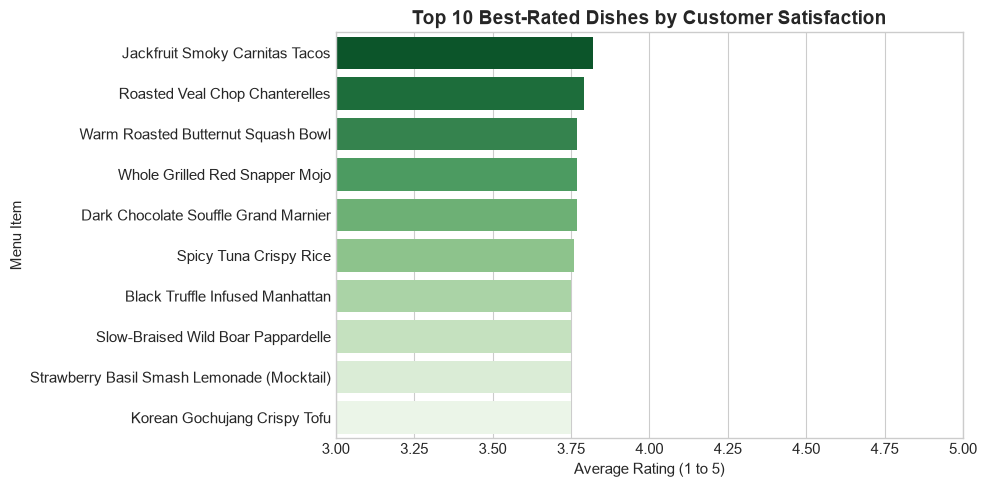

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=best_rated, x="average_rating", y="item_name", palette="Greens_r", ax=ax)
ax.set_title("Top 10 Best-Rated Dishes by Customer Satisfaction", fontsize=14, fontweight="bold")
ax.set_xlabel("Average Rating (1 to 5)")
ax.set_xlim(3.0, 5.0)
ax.set_ylabel("Menu Item")
plt.tight_layout()
plt.show()


## 8. Poorly Rated Dishes
Items receiving the lowest average ratings, indicating preparation inconsistencies, taste issues, or poor presentation.


In [17]:
poor_rated = menu_df.sort_values(by="average_rating", ascending=True).head(10)
poor_rated[["item_id", "item_name", "category_name", "average_rating", "rating_trend", "item_popularity"]]


,item_id,item_name,category_name,average_rating,rating_trend,item_popularity
141,ITEM-008,Reserve Osetra Caviar Blinis,Appetizers & Small Plates,3.32,0.992,814
92,ITEM-075,Seafood Bouillabaisse Saffron Rouille,Chef Specials & Seafood,3.35,0.459,2939
137,ITEM-105,Artisanal Vegan Charcuterie Board,Vegan & Plant-Based Creations,3.38,0.582,2205
42,ITEM-065,Jumbo Lump Crab Cakes (2pcs),Chef Specials & Seafood,3.43,-0.687,5182
17,ITEM-135,Red Sangria Pitcher (House Wine),Signature Cocktails & Mocktails,3.46,-0.245,7727
49,ITEM-013,Loaded Queso Nachos,Appetizers & Small Plates,3.47,-0.067,12296
91,ITEM-078,Burrata Caprese Heirloom Salad,Farm-Fresh Salads & Grain Bowls,3.47,-0.242,6678
125,ITEM-060,Pepper-Crusted Bison Tenderloin,Prime Steaks & Butcher Cuts,3.48,-0.294,1145
89,ITEM-018,Prime Wagyu Truffle Burger,Artisanal Burgers & Handhelds,3.49,-0.292,4045
146,ITEM-143,Organic Earl Grey Loose Leaf Tea,Specialty Coffee & Beverages,3.51,-0.065,9333


C:\Users\HP 250 G9\AppData\Local\Temp\ipykernel_23420\46724032.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=poor_rated, x="average_rating", y="item_name", palette="copper", ax=ax)


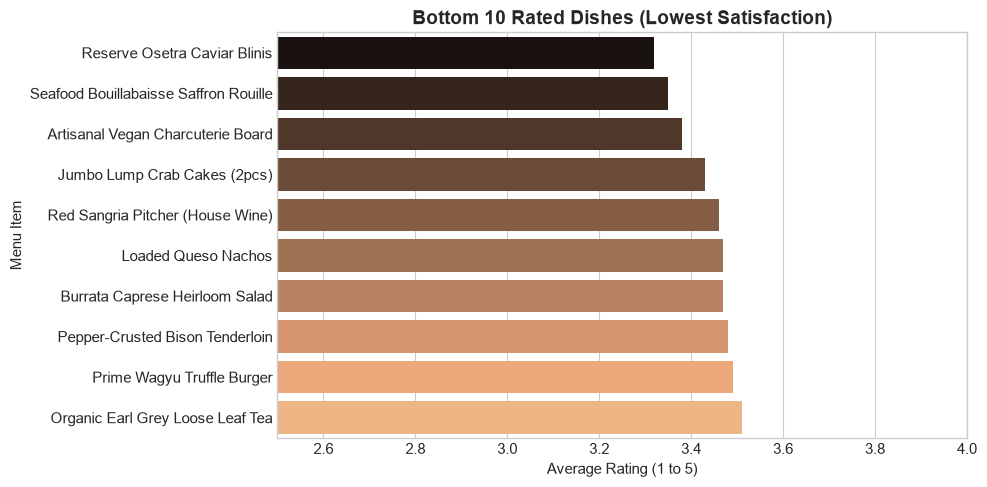

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=poor_rated, x="average_rating", y="item_name", palette="copper", ax=ax)
ax.set_title("Bottom 10 Rated Dishes (Lowest Satisfaction)", fontsize=14, fontweight="bold")
ax.set_xlabel("Average Rating (1 to 5)")
ax.set_xlim(2.5, 4.0)
ax.set_ylabel("Menu Item")
plt.tight_layout()
plt.show()


## 9. Popular Menu Categories
Performance and contribution across all 10 menu categories (revenue, volume, average margin).


In [19]:
cat_summary = menu_df.groupby("category_name").agg(
    total_items=("item_id", "count"),
    total_units_sold=("item_popularity", "sum"),
    total_revenue=("item_revenue", "sum"),
    total_profit=("contribution_margin", "sum"),
    avg_profit_pct=("profit_percentage", "mean"),
    avg_rating=("average_rating", "mean")
).reset_index().sort_values(by="total_revenue", ascending=False)
cat_summary


,category_name,total_items,total_units_sold,total_revenue,total_profit,avg_profit_pct,avg_rating
5,Prime Steaks & Butcher Cuts,15,81198,3108065.69,1653379.49,55.744000,3.618000
9,Wood-Fired Pizzas & Pastas,15,147389,2912670.28,1591770.48,57.682667,3.604000
2,Chef Specials & Seafood,15,77803,2426583.63,1261109.33,53.940000,3.631333
1,Artisanal Burgers & Handhelds,15,141860,2257639.24,1045112.14,49.932000,3.634000
6,Signature Cocktails & Mocktails,15,153448,2109485.80,1625688.70,76.546667,3.633333
3,Farm-Fresh Salads & Grain Bowls,15,139419,2057565.41,1173473.51,58.830000,3.622000
8,Vegan & Plant-Based Creations,15,118099,1893098.78,1210531.68,65.310667,3.618000
0,Appetizers & Small Plates,15,142317,1856375.57,597393.02,37.122000,3.594667
4,Handcrafted Desserts & Pastries,15,137273,1404295.58,867294.58,66.355333,3.614667
7,Specialty Coffee & Beverages,15,172102,956418.80,722773.75,75.240667,3.592000


C:\Users\HP 250 G9\AppData\Local\Temp\ipykernel_23420\2219953087.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_summary, x="total_revenue", y="category_name", palette="Blues_r", ax=ax1)
C:\Users\HP 250 G9\AppData\Local\Temp\ipykernel_23420\2219953087.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_summary, x="avg_profit_pct", y="category_name", palette="viridis", ax=ax2)


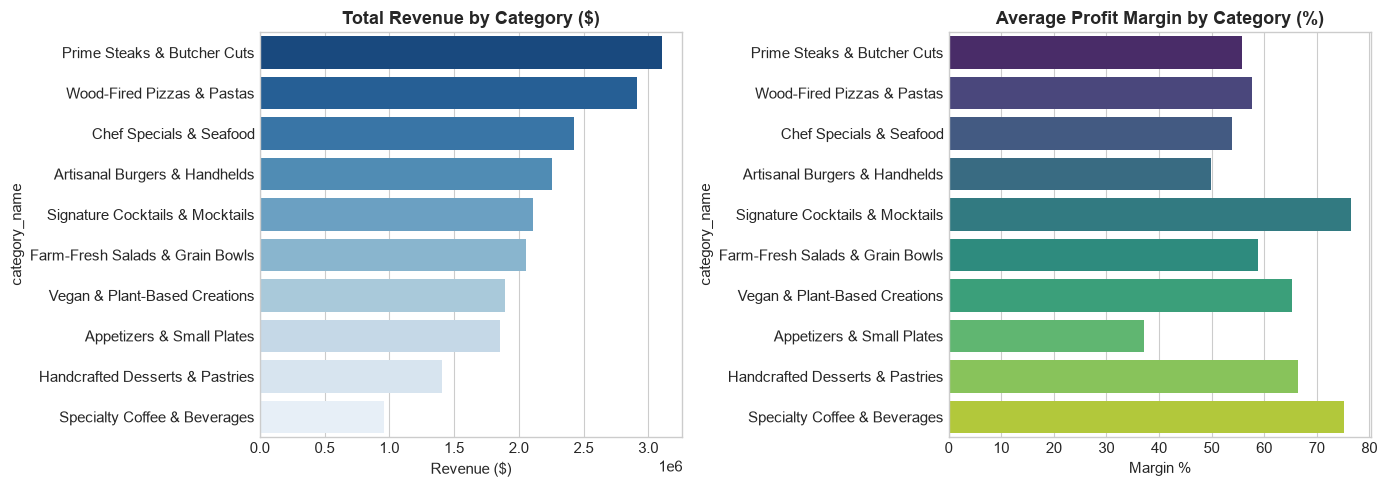

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=cat_summary, x="total_revenue", y="category_name", palette="Blues_r", ax=ax1)
ax1.set_title("Total Revenue by Category ($)", fontweight="bold")
ax1.set_xlabel("Revenue ($)")

sns.barplot(data=cat_summary, x="avg_profit_pct", y="category_name", palette="viridis", ax=ax2)
ax2.set_title("Average Profit Margin by Category (%)", fontweight="bold")
ax2.set_xlabel("Margin %")
plt.tight_layout()
plt.show()


## 10. Peak Ordering Periods
Temporal dynamics: peak dining hours (Lunch 12-2 PM vs Dinner 6-9 PM) and day-of-week demand curves.


C:\Users\HP 250 G9\AppData\Local\Temp\ipykernel_23420\1114184393.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=daily_orders, x="day_name", y="order_id", palette="Purples_r", ax=ax2)


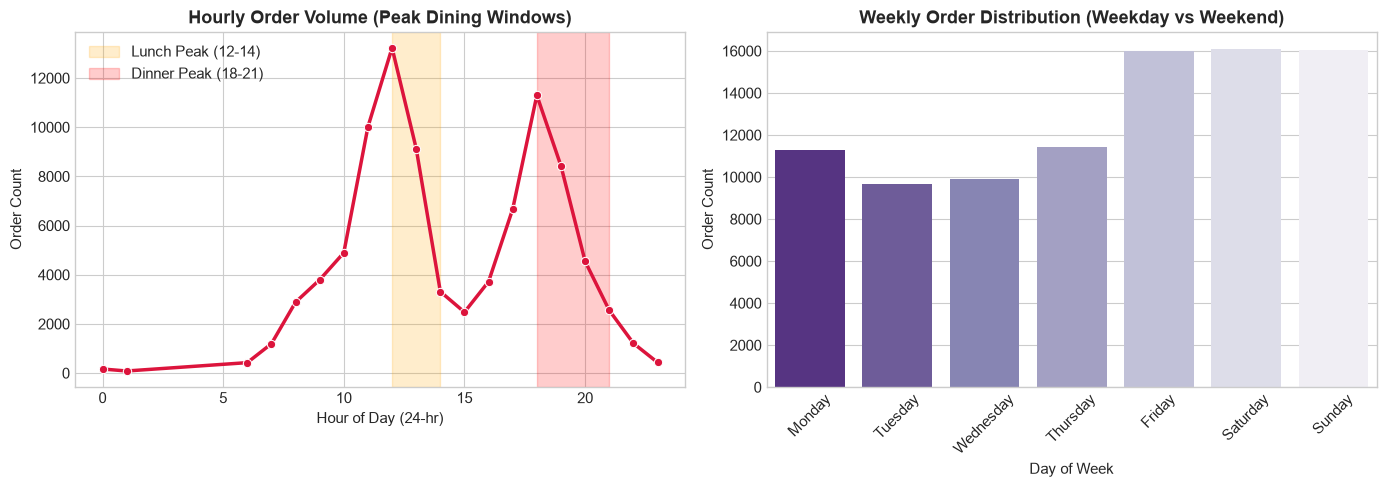

In [21]:
orders_df["order_hour"] = pd.to_datetime(orders_df["order_time"].astype(str), format="%H:%M:%S", errors="coerce").dt.hour
orders_df["day_name"] = pd.to_datetime(orders_df["order_date"]).dt.day_name()

hourly_orders = orders_df.groupby("order_hour")["order_id"].count().reset_index()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daily_orders = orders_df.groupby("day_name")["order_id"].count().reindex(day_order).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=hourly_orders, x="order_hour", y="order_id", marker="o", color="crimson", linewidth=2.5, ax=ax1)
ax1.set_title("Hourly Order Volume (Peak Dining Windows)", fontweight="bold")
ax1.set_xlabel("Hour of Day (24-hr)")
ax1.set_ylabel("Order Count")
ax1.axvspan(12, 14, color="orange", alpha=0.2, label="Lunch Peak (12-14)")
ax1.axvspan(18, 21, color="red", alpha=0.2, label="Dinner Peak (18-21)")
ax1.legend()

sns.barplot(data=daily_orders, x="day_name", y="order_id", palette="Purples_r", ax=ax2)
ax2.set_title("Weekly Order Distribution (Weekday vs Weekend)", fontweight="bold")
ax2.set_xlabel("Day of Week")
ax2.set_ylabel("Order Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 11. Location-Wise Sales Patterns
Disparities and performance benchmarks across all 20 restaurant locations, cities, and store tiers.


In [22]:
loc_perf = orders_df.groupby("location_id").agg(
    order_count=("order_id", "count"),
    gross_revenue=("total_amount", "sum"),
    avg_ticket_size=("total_amount", "mean")
).reset_index()

loc_perf = pd.merge(loc_perf, restaurants_df[["location_id", "name", "city", "location_tier", "cost_index"]], on="location_id")
loc_perf = loc_perf.sort_values(by="gross_revenue", ascending=False)
loc_perf.head(10)


,location_id,order_count,gross_revenue,avg_ticket_size,name,city,location_tier,cost_index
0,LOC-001,6493,1762436.81,271.436441,DineIQ Flagship Downtown,New York,Flagship,1.35
11,LOC-012,6218,1680631.52,270.284902,DineIQ Los Angeles Beverly,Los Angeles,Flagship,1.38
9,LOC-010,5983,1611512.05,269.348496,DineIQ San Francisco Embarcadero,San Francisco,Flagship,1.40
16,LOC-017,5642,1519177.63,269.262253,DineIQ Orlando Theme Park Outpost,Orlando,Family Destination,1.08
3,LOC-004,5503,1478621.57,268.693725,DineIQ Chicago Magnificent Mile,Chicago,Flagship,1.25
15,LOC-016,5325,1429718.61,268.491758,DineIQ Miami South Beach,Miami,Coastal Boardwalk,1.28
12,LOC-013,5260,1420104.10,269.981768,DineIQ Santa Monica Promenade,Santa Monica,Coastal Boardwalk,1.32
1,LOC-002,4970,1340653.62,269.749219,DineIQ Financial Center,New York,Urban Corporate,1.30
7,LOC-008,4303,1169565.16,271.802268,DineIQ Houston Galleria,Houston,Suburban Mall,1.05
5,LOC-006,4259,1148439.51,269.650038,DineIQ Austin Downtown,Austin,Urban Dining,1.10


C:\Users\HP 250 G9\AppData\Local\Temp\ipykernel_23420\3076893534.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=loc_perf.head(10), x="gross_revenue", y="name", palette="plasma", ax=ax1)
C:\Users\HP 250 G9\AppData\Local\Temp\ipykernel_23420\3076893534.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=loc_perf, x="location_tier", y="avg_ticket_size", palette="Set2", ax=ax2)


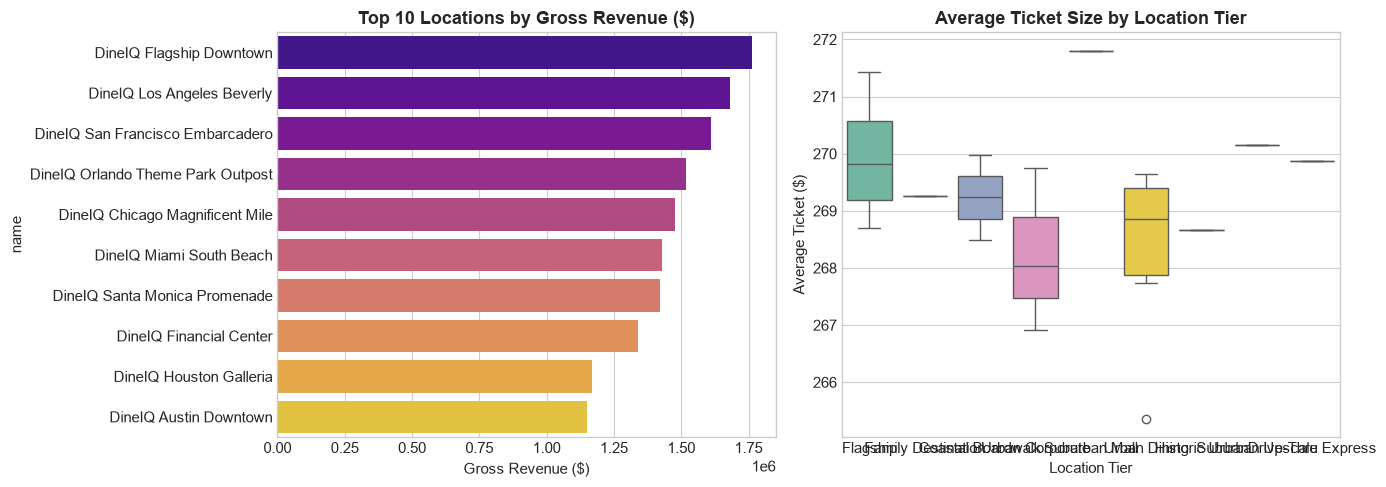

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=loc_perf.head(10), x="gross_revenue", y="name", palette="plasma", ax=ax1)
ax1.set_title("Top 10 Locations by Gross Revenue ($)", fontweight="bold")
ax1.set_xlabel("Gross Revenue ($)")

sns.boxplot(data=loc_perf, x="location_tier", y="avg_ticket_size", palette="Set2", ax=ax2)
ax2.set_title("Average Ticket Size by Location Tier", fontweight="bold")
ax2.set_xlabel("Location Tier")
ax2.set_ylabel("Average Ticket ($)")
plt.tight_layout()
plt.show()


## 12. Channel-Wise Ordering Patterns
Order channel dynamics: Dine-in vs Takeout vs Delivery volume, spend, and ticket sizes.


In [24]:
channel_summary = orders_df.groupby("order_type").agg(
    total_orders=("order_id", "count"),
    total_sales=("total_amount", "sum"),
    avg_ticket=("total_amount", "mean"),
    avg_discount=("discount_amount", "mean")
).reset_index()
channel_summary["pct_share"] = (channel_summary["total_orders"] / channel_summary["total_orders"].sum() * 100).round(2)
channel_summary


,order_type,total_orders,total_sales,avg_ticket,avg_discount,pct_share
0,DELIVERY,18112,5178506.96,285.915799,6.004765,20.02
1,DINE_IN,40662,11415011.81,280.729227,5.938614,44.94
2,DRIVE_THRU,9139,2238078.64,244.893166,5.892945,10.10
3,TAKEOUT,22558,5525343.05,244.939403,5.881589,24.93


C:\Users\HP 250 G9\AppData\Local\Temp\ipykernel_23420\2637488092.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel_summary, x="order_type", y="avg_ticket", palette="pastel", ax=ax2)


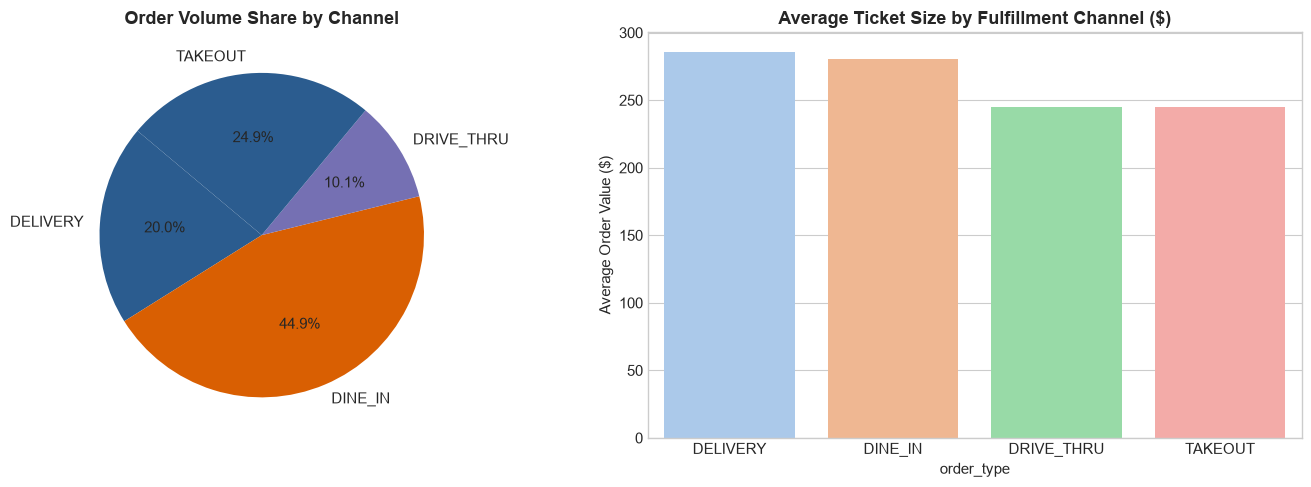

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.pie(channel_summary["total_orders"], labels=channel_summary["order_type"], autopct="%1.1f%%", colors=["#2b5c8f", "#d95f02", "#7570b3"], startangle=140)
ax1.set_title("Order Volume Share by Channel", fontweight="bold")

sns.barplot(data=channel_summary, x="order_type", y="avg_ticket", palette="pastel", ax=ax2)
ax2.set_title("Average Ticket Size by Fulfillment Channel ($)", fontweight="bold")
ax2.set_ylabel("Average Order Value ($)")
plt.tight_layout()
plt.show()


## 13. Promotion-Driven Sales
Promotion uptake, discount sensitivity, and evaluation of misleading discounts vs regular promotions.


In [26]:
orders_df["has_promotion"] = orders_df["promotion_id"].notnull() & (orders_df["promotion_id"] != "")
promo_perf = orders_df.groupby("has_promotion").agg(
    order_count=("order_id", "count"),
    total_revenue=("total_amount", "sum"),
    avg_order_value=("total_amount", "mean"),
    avg_discount=("discount_amount", "mean")
).reset_index()
promo_perf["share_pct"] = (promo_perf["order_count"] / promo_perf["order_count"].sum() * 100).round(2)
promo_perf


,has_promotion,order_count,total_revenue,avg_order_value,avg_discount,share_pct
0,False,60010,16518078.11,275.255426,0.077247,66.33
1,True,30461,7838862.35,257.340939,17.469261,33.67


C:\Users\HP 250 G9\AppData\Local\Temp\ipykernel_23420\1389840208.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=promo_perf, x="has_promotion", y="order_count", palette=["#95a5a6", "#2ecc71"], ax=ax1)
C:\Users\HP 250 G9\AppData\Local\Temp\ipykernel_23420\1389840208.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(["Non-Promotional", "Promotional"])
C:\Users\HP 250 G9\AppData\Local\Temp\ipykernel_23420\1389840208.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=promo_perf, x="has_promotion", y="avg_order_value", palette=["#95a5a6", "

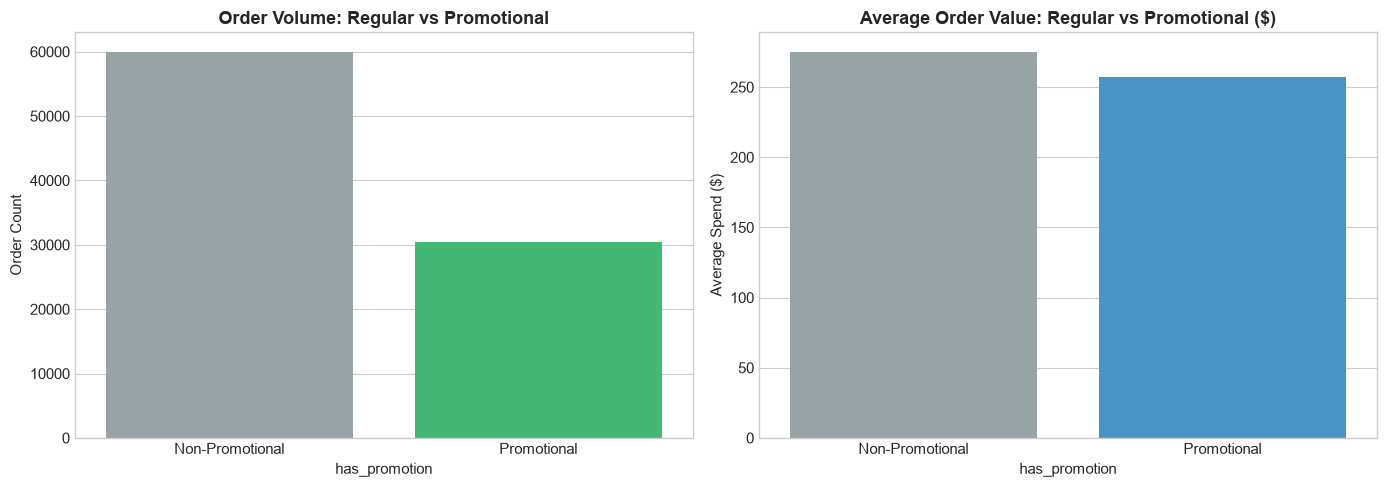

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=promo_perf, x="has_promotion", y="order_count", palette=["#95a5a6", "#2ecc71"], ax=ax1)
ax1.set_title("Order Volume: Regular vs Promotional", fontweight="bold")
ax1.set_xticklabels(["Non-Promotional", "Promotional"])
ax1.set_ylabel("Order Count")

sns.barplot(data=promo_perf, x="has_promotion", y="avg_order_value", palette=["#95a5a6", "#3498db"], ax=ax2)
ax2.set_title("Average Order Value: Regular vs Promotional ($)", fontweight="bold")
ax2.set_xticklabels(["Non-Promotional", "Promotional"])
ax2.set_ylabel("Average Spend ($)")
plt.tight_layout()
plt.show()


## 14. Executive Synthesis & Strategic Recommendations
### Summary of Findings:
- **Stars (High Profit, High Volume):** Protect recipes and pricing; avoid unnecessary promotional discounting.
- **Plowhorses (Low Margin, High Volume):** High popularity items driving kitchen throughput; apply targeted ingredient cost optimization or modest 3-5% price raises.
- **Puzzles (High Margin, Low Volume):** High profit potential constrained by visibility; deploy targeted combo meal bundles and digital app placement.
- **Dogs (Low Margin, Low Volume):** Prime candidates for phase-out to eliminate prep overhead and inventory spoilage.
- **Operational Cadence:** Significant surge between 12-2 PM (Lunch) and 6-9 PM (Dinner), with peak delivery ordering occurring on weekends.
